<a href="https://colab.research.google.com/github/AyeshaThapa/Retail-sales-data/blob/main/sentimentanalysis1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

In [ ]:
#Load datasets
twitter_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/twitter_data.csv')
apps_data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/apps_data.csv')

In [ ]:
#Display basic info
print("\n twitter data info")
print(twitter_df.info())
print("\n apps_data.info")
print(apps_data.info)


 twitter data info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162980 entries, 0 to 162979
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   clean_text  162976 non-null  object 
 1   category    162973 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.5+ MB
None

 apps_data.info
<bound method DataFrame.info of       Unnamed: 0                                                App  \
0              0     Photo Editor & Candy Camera & Grid & ScrapBook   
1              1                                Coloring book moana   
2              2  U Launcher Lite – FREE Live Cool Themes, Hide ...   
3              3                              Sketch - Draw & Paint   
4              4              Pixel Draw - Number Art Coloring Book   
...          ...                                                ...   
9654       10836                                   Sya9a Maroc - FR   
9655       10837            

In [ ]:
print("\n apps data info")
print(apps_data.info())
print("\n twitter data info")
print(apps_data.head)


 apps data info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9659 entries, 0 to 9658
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      9659 non-null   int64  
 1   App             9659 non-null   object 
 2   Category        9659 non-null   object 
 3   Rating          8196 non-null   float64
 4   Reviews         9659 non-null   int64  
 5   Size            8432 non-null   object 
 6   Installs        9659 non-null   object 
 7   Type            9658 non-null   object 
 8   Price           9659 non-null   object 
 9   Content Rating  9659 non-null   object 
 10  Genres          9659 non-null   object 
 11  Last Updated    9659 non-null   object 
 12  Current Ver     9651 non-null   object 
 13  Android Ver     9657 non-null   object 
dtypes: float64(1), int64(2), object(11)
memory usage: 1.0+ MB
None

 twitter data info
<bound method NDFrame.head of       Unnamed: 0                      

In [ ]:
#Check for missing values
print("\n apps data missing values")
print(apps_data.isnull().sum())
print("\n twitter data missing values")
print(twitter_df.isnull().sum())


 apps data missing values
Unnamed: 0           0
App                  0
Category             0
Rating            1463
Reviews              0
Size              1227
Installs             0
Type                 1
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          8
Android Ver          2
dtype: int64

 twitter data missing values
clean_text    4
category      7
dtype: int64


In [ ]:
#Check dataset sizes
print("\n apps data shape")
print(apps_data.shape)
print("\n twitter data shape")
print(twitter_df.shape)


 apps data shape
(9659, 14)

 twitter data shape
(162980, 2)


In [ ]:
#Basic descriptive stats(numerical columns only)
print("\n twitter data stats")
print(twitter_df.describe(include='all'))


 twitter data stats
                                               clean_text       category
count                                              162976  162973.000000
unique                                             162976            NaN
top     never seen duffer person like you want modi no...            NaN
freq                                                    1            NaN
mean                                                  NaN       0.225436
std                                                   NaN       0.781279
min                                                   NaN      -1.000000
25%                                                   NaN       0.000000
50%                                                   NaN       0.000000
75%                                                   NaN       1.000000
max                                                   NaN       1.000000


In [ ]:
print("\n apps data stats")
print(apps_data.describe(include='all'))


 apps data stats
          Unnamed: 0                                            App Category  \
count    9659.000000                                           9659     9659   
unique           NaN                                           9659       33   
top              NaN  iHoroscope - 2018 Daily Horoscope & Astrology   FAMILY   
freq             NaN                                              1     1832   
mean     5666.172896                                            NaN      NaN   
std      3102.362863                                            NaN      NaN   
min         0.000000                                            NaN      NaN   
25%      3111.500000                                            NaN      NaN   
50%      5814.000000                                            NaN      NaN   
75%      8327.500000                                            NaN      NaN   
max     10840.000000                                            NaN      NaN   

             Rating  

TEXT PREPROCESSING & SENTIMENT NODEL TRAINING

In [ ]:
import pandas as pd
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
twitter_data= pd.read_csv("/content/drive/MyDrive/Colab Notebooks/twitter_data.csv")

In [ ]:
TEXT_COLUMN="clean_text"
LABEL_COLUMN="category"

In [ ]:
def clean_text(text):
  text = str(text).lower()
  text = re.sub(r"http\S+\s+|https\S+\s+", '', text)
  text = re.sub(r'@\w+','',text)
  text = text.translate(str.maketrans('', '', string.punctuation))
  text = re.sub(r'\w*\d\w*','',text)
  return text # Added return statement

In [ ]:
twitter_data["clean_text"] = twitter_data["clean_text"].apply(lambda x: clean_text(x))

In [ ]:
twitter_data.dropna(subset=['category'], inplace=True)

X = twitter_data['clean_text']
y = twitter_data['category']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
vectorizer = TfidfVectorizer(max_features=5000, stop_words="english")
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test_vec)

print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

print("\n--- Accuracy ---")
print(accuracy_score(y_test, y_pred))


--- Confusion Matrix ---
[[ 5401   847   982]
 [  120 10525   316]
 [  718  1786 11900]]

--- Classification Report ---
              precision    recall  f1-score   support

        -1.0       0.87      0.75      0.80      7230
         0.0       0.80      0.96      0.87     10961
         1.0       0.90      0.83      0.86     14404

    accuracy                           0.85     32595
   macro avg       0.86      0.84      0.85     32595
weighted avg       0.86      0.85      0.85     32595


--- Accuracy ---
0.8536892161374444


DATA VISUALIZING

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

/tmp/ipython-input-671633067.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=twitter_data["category"], palette="viridis")


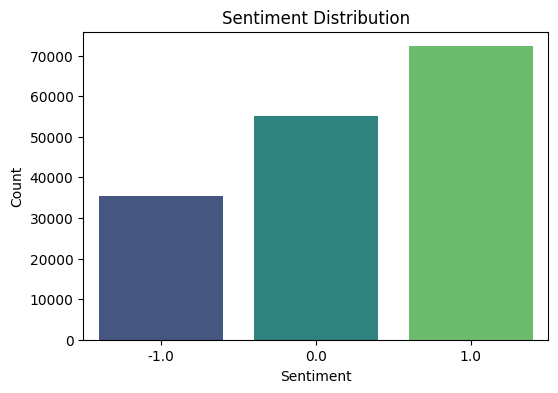

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x=twitter_data["category"], palette="viridis")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

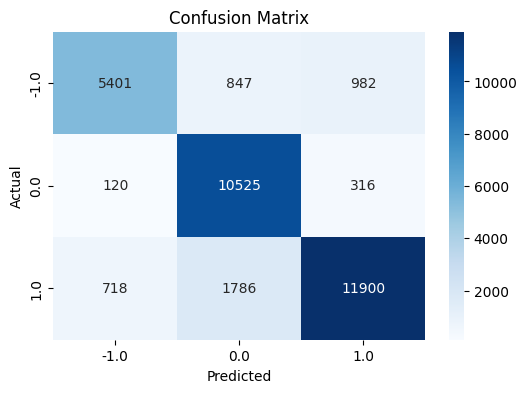

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

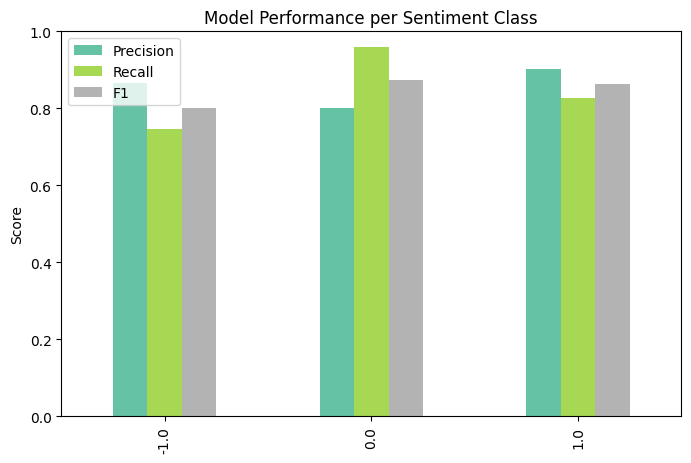

In [ ]:
from sklearn.metrics import precision_recall_fscore_support

metrics = precision_recall_fscore_support(y_test, y_pred, average=None, labels=model.classes_)
metrics_df = pd.DataFrame(metrics[:-1], index=["Precision", "Recall", "F1"], columns=model.classes_).T

metrics_df.plot(kind="bar", figsize=(8,5), colormap="Set2")
plt.title("Model Performance per Sentiment Class")
plt.ylabel("Score")
plt.ylim(0,1)
plt.show()

In [ ]:
from wordcloud import WordCloud

positive_text = " ".join(twitter_data[twitter_data[LABEL_COLUMN]== 1.0]["clean_text"])
negative_text = " ".join(twitter_data[twitter_data[LABEL_COLUMN]== -1.0]["clean_text"])

plt.figure(figsize=(12,6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

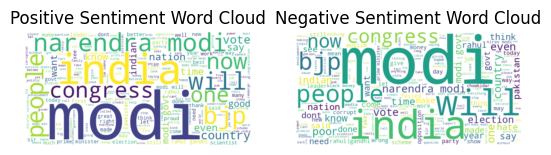

In [ ]:
wordcloud_positive = WordCloud(width=800, height=400, background_color='white').generate(positive_text)
wordcloud_negative = WordCloud(width=800, height=400, background_color='white').generate(negative_text)

plt.subplot(1, 2, 1)
plt.imshow(wordcloud_positive, interpolation='bilinear')
plt.axis("off")
plt.title("Positive Sentiment Word Cloud")

plt.subplot(1, 2, 2)
plt.imshow(wordcloud_negative, interpolation='bilinear')
plt.axis("off")
plt.title("Negative Sentiment Word Cloud")

plt.show()

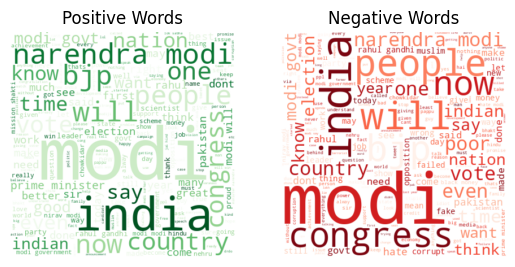

In [ ]:
#Positive word cloud
plt.subplot(1,2,1)
wc_pos = WordCloud(width=400, height=400, background_color="white", colormap="Greens").generate(positive_text)
plt.imshow(wc_pos, interpolation="bilinear")
plt.axis("off")
plt.title("Positive Words")

# Negative word cloud
plt.subplot(1,2,2)
wc_neg = WordCloud(width=400, height=400, background_color="white", colormap="Reds").generate(negative_text)
plt.imshow(wc_neg, interpolation="bilinear")
plt.axis("off")
plt.title("Negative Words")

plt.show()